In [25]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np

# Import modules
from model.data_loader_frag import load_fragments
from model.problem import AssemblyProblem
from algorithms.simulated_annealing import simulated_annealing

In [26]:
# Import fragments and optimization problem
fragments = load_fragments()
problem = AssemblyProblem(fragments)

## Simulated Annealing

In [27]:


# =========================
# RUN SIMULATED ANNEALING
# =========================

# Simple example: no pair constraints for now
result = simulated_annealing(
    fragments=fragments,
    T0=100.0,
    alpha=0.995,
    max_iterations=5000,
    seed=42,
    verbose=True
)

[iter      1] T=  100.0000 current=    40199.00 best=    40199.00 accept_rate= 0.000
[iter    500] T=    8.1982 current=    25348.00 best=    25348.00 accept_rate= 0.170
[iter   1000] T=    0.6687 current=    21984.00 best=    21984.00 accept_rate= 0.070
[iter   1500] T=    0.0546 current=    20181.00 best=    20181.00 accept_rate= 0.080
[iter   2000] T=    0.0044 current=    19276.00 best=    19276.00 accept_rate= 0.020
[iter   2500] T=    0.0004 current=    18461.00 best=    18461.00 accept_rate= 0.030
[iter   3000] T=    0.0000 current=    18406.00 best=    18406.00 accept_rate= 0.060
[iter   3500] T=    0.0000 current=    18229.00 best=    18229.00 accept_rate= 0.060
Early stopping at iteration 3675 (T < 1e-06)

Simulated Annealing completed!
Initial cost: 40199.0
Final best cost: 17530.0
Improvement: 22669.0 (56.4%)


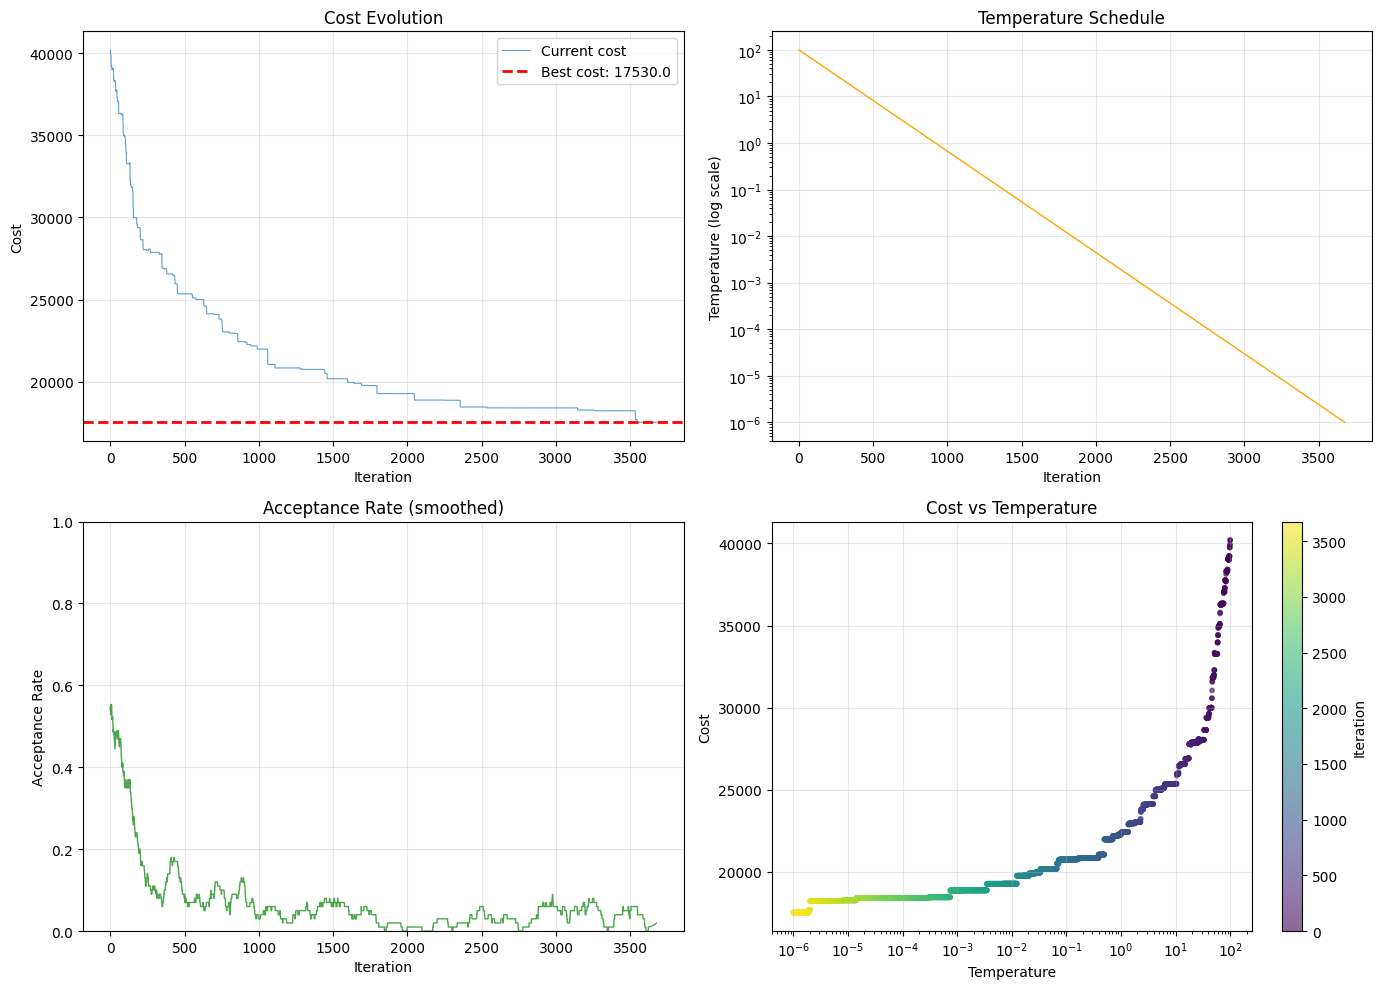

Cost reduction: 22669.0
Relative improvement: 56.4%


In [28]:
# =========================
# VISUALIZATIONS
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Cost over iterations
ax = axes[0, 0]
ax.plot(result['cost_history'], linewidth=0.8, alpha=0.7, label='Current cost')
ax.axhline(result['best_cost'], color='r', linestyle='--', linewidth=2, label=f"Best cost: {result['best_cost']:.1f}")
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost')
ax.set_title('Cost Evolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Temperature decay
ax = axes[0, 1]
ax.semilogy(result['temperature_history'], linewidth=1, color='orange')
ax.set_xlabel('Iteration')
ax.set_ylabel('Temperature (log scale)')
ax.set_title('Temperature Schedule')
ax.grid(True, alpha=0.3)

# Plot 3: Acceptance rate
ax = axes[1, 0]
ax.plot(result['acceptance_rate_history'], linewidth=1, color='green', alpha=0.7)
ax.set_xlabel('Iteration')
ax.set_ylabel('Acceptance Rate')
ax.set_title('Acceptance Rate (smoothed)')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Plot 4: Cost vs Temperature
ax = axes[1, 1]
scatter = ax.scatter(result['temperature_history'], result['cost_history'], 
                     c=range(len(result['cost_history'])), cmap='viridis', 
                     s=10, alpha=0.6)
ax.set_xlabel('Temperature')
ax.set_ylabel('Cost')
ax.set_title('Cost vs Temperature')
ax.set_xscale('log')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Iteration')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cost reduction: {result['cost_history'][0] - result['best_cost']:.1f}")
print(f"Relative improvement: {100*(result['cost_history'][0] - result['best_cost'])/abs(result['cost_history'][0]):.1f}%")

In [29]:
# =========================
# SOLUTION ANALYSIS
# =========================

best_perm = result['best_solution']
print("=" * 70)
print("BEST SOLUTION FOUND")
print("=" * 70)
print(f"\nPermutation order (fragment IDs):")
print(best_perm)
print(f"\nTotal cost: {result['best_cost']:.2f}")

# Algorithm statistics
print("\n" + "=" * 70)
print("ALGORITHM STATISTICS")
print("=" * 70)
print(f"Total iterations: {len(result['cost_history']) - 1}")
print(f"Initial cost: {result['cost_history'][0]:.2f}")
print(f"Final best cost: {result['best_cost']:.2f}")
print(f"Final current cost: {result['current_cost']:.2f}")
print(f"Improvement: {result['cost_history'][0] - result['best_cost']:.2f}")
improvement_pct = 100 * (result['cost_history'][0] - result['best_cost']) / abs(result['cost_history'][0])
print(f"Relative improvement: {improvement_pct:.2f}%")

print(f"\nBreaks: {result['best_breaks']}")
print(f"Contigs: {result['best_contigs']}")
print(f"Total overlap: {result['best_total_overlap']:.2f}")

# Acceptance statistics
acceptance_rates = result['acceptance_rate_history']
print(f"\nAverage acceptance rate (early): {np.mean(acceptance_rates[:len(acceptance_rates)//4]):.2%}")
print(f"Average acceptance rate (mid): {np.mean(acceptance_rates[len(acceptance_rates)//4:len(acceptance_rates)//2]):.2%}")
print(f"Average acceptance rate (late): {np.mean(acceptance_rates[3*len(acceptance_rates)//4:]):.2%}")
print(f"Overall average acceptance rate: {np.mean(acceptance_rates):.2%}")

BEST SOLUTION FOUND

Permutation order (fragment IDs):
['simulated_chromosome_frag_16', 'simulated_chromosome_frag_4', 'simulated_chromosome_frag_60', 'simulated_chromosome_frag_44', 'simulated_chromosome_frag_24', 'simulated_chromosome_frag_67', 'simulated_chromosome_frag_63', 'simulated_chromosome_frag_17', 'simulated_chromosome_frag_12', 'simulated_chromosome_frag_32', 'simulated_chromosome_frag_9', 'simulated_chromosome_frag_64', 'simulated_chromosome_frag_48', 'simulated_chromosome_frag_3', 'simulated_chromosome_frag_41', 'simulated_chromosome_frag_30', 'simulated_chromosome_frag_58', 'simulated_chromosome_frag_54', 'simulated_chromosome_frag_37', 'simulated_chromosome_frag_6', 'simulated_chromosome_frag_18', 'simulated_chromosome_frag_50', 'simulated_chromosome_frag_40', 'simulated_chromosome_frag_33', 'simulated_chromosome_frag_8', 'simulated_chromosome_frag_38', 'simulated_chromosome_frag_7', 'simulated_chromosome_frag_5', 'simulated_chromosome_frag_47', 'simulated_chromosome_f

In [30]:
# =========================
# PARAMETER SENSITIVITY ANALYSIS
# =========================

temperatures = [50, 100, 200]
cooling_rates = [0.99, 0.995, 0.999]

results_grid = {}

print("Testing different parameter combinations...")
print("(This may take a minute)\n")

for T0 in temperatures:
    for alpha in cooling_rates:
        key = f"T0={T0}, α={alpha}"
        print(f"  {key}...", end=" ", flush=True)

        res = simulated_annealing(
            fragments=fragments,
            T0=T0,
            alpha=alpha,
            max_iterations=5000,
            seed=42,
            verbose=False
        )

        results_grid[key] = res['best_cost']
        print(f"best_cost={res['best_cost']:.1f}")

print("\n" + "=" * 70)
print("PARAMETER SENSITIVITY RESULTS")
print("=" * 70)
print(f"{'T0 / α':<10}", end="")
for alpha in cooling_rates:
    print(f"{alpha:<15}", end="")
print()
print("-" * 60)

for T0 in temperatures:
    print(f"{T0:<10}", end="")
    for alpha in cooling_rates:
        key = f"T0={T0}, α={alpha}"
        cost = results_grid[key]
        print(f"{cost:<15.1f}", end="")
    print()

Testing different parameter combinations...
(This may take a minute)

  T0=50, α=0.99... best_cost=21249.0
  T0=50, α=0.995... best_cost=17479.0
  T0=50, α=0.999... best_cost=16996.0
  T0=100, α=0.99... best_cost=21451.0
  T0=100, α=0.995... best_cost=17530.0
  T0=100, α=0.999... best_cost=19025.0
  T0=200, α=0.99... best_cost=20176.0
  T0=200, α=0.995... best_cost=17058.0
  T0=200, α=0.999... best_cost=17133.0

PARAMETER SENSITIVITY RESULTS
T0 / α    0.99           0.995          0.999          
------------------------------------------------------------
50        21249.0        17479.0        16996.0        
100       21451.0        17530.0        19025.0        
200       20176.0        17058.0        17133.0        
